# California Real Estate Investment: Identifying High-Value Markets
**Author:** Ali AKYEL | **Project Type:** Binary Classification & Unsupervised Learning

## Business Problem & Objective
A real estate investment firm is looking to expand into the California market. Their strategy focuses exclusively on premium, high-value neighborhoods (defined as the top 20% of the market). However, when assessing new or rapidly developing areas, exact median house prices are often missing, outdated, or unreliable. 

**The Objective:** Build a machine learning pipeline capable of identifying whether a neighborhood belongs to the "High-Value" tier based solely on its geographic coordinates, demographics, and local infrastructure—without relying on current market prices.

## The Dataset
The dataset contains information from the California census. Key features include:
* **Geographic:** Longitude, Latitude, Ocean Proximity
* **Demographic:** Median Income, Population, Households
* **Infrastructure:** Total Rooms, Total Bedrooms, Housing Median Age


## 1. Setup and Data Loading

In this section, the necessary libraries are imported, a global random seed is set to ensure complete reproducibility, and the given dataset is loaded.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the data
df = pd.read_csv('housing.csv')
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (20640, 10)


## 2. Target Creation & Feature Engineering
We must convert the regression problem into a binary classification problem. (Track B)
1. We define a "High Value" area as the top 20% of the `median_house_value`.
2. **Crucial Step:** We immediately drop the original `median_house_value` column to prevent data leakage. If we keep it, the model will cheat and fail to generalize to new data.
3. We create contextual features (like `rooms_per_household`) to give the model better logical inputs.

In [2]:
# 1. Calculate the 80th percentile threshold (Top 20%)
threshold = df['median_house_value'].quantile(0.80)

# 2. Create binary target: 1 if >= threshold, else 0
df['high_value'] = (df['median_house_value'] >= threshold).astype(int)

# 3. CRITICAL: Drop the original target to prevent data leakage
df = df.drop('median_house_value', axis=1)

# 4. Feature Engineering: Create contextual ratios
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Display basic info and missing values
print(f"Threshold for top 20%: ${threshold:,.2f}")
print("\nTarget distribution (Class Imbalance):")
print(df['high_value'].value_counts(normalize=True))
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Threshold for top 20%: $290,000.00

Target distribution (Class Imbalance):
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64

Missing Values:
total_bedrooms       207
bedrooms_per_room    207
dtype: int64


## 3. Exploratory Data Analysis (EDA)

Before building predictive models, we visually inspect the data to confirm that location and income have a tangible relationship with high-value properties.

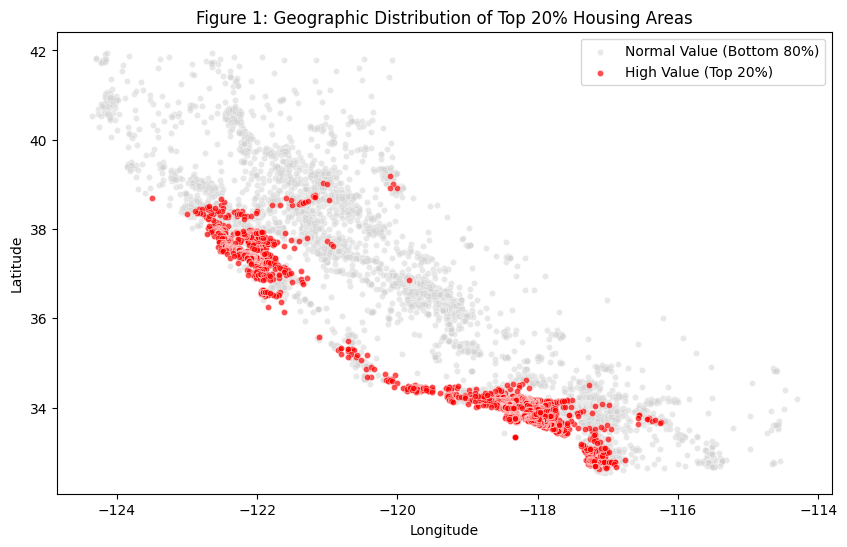

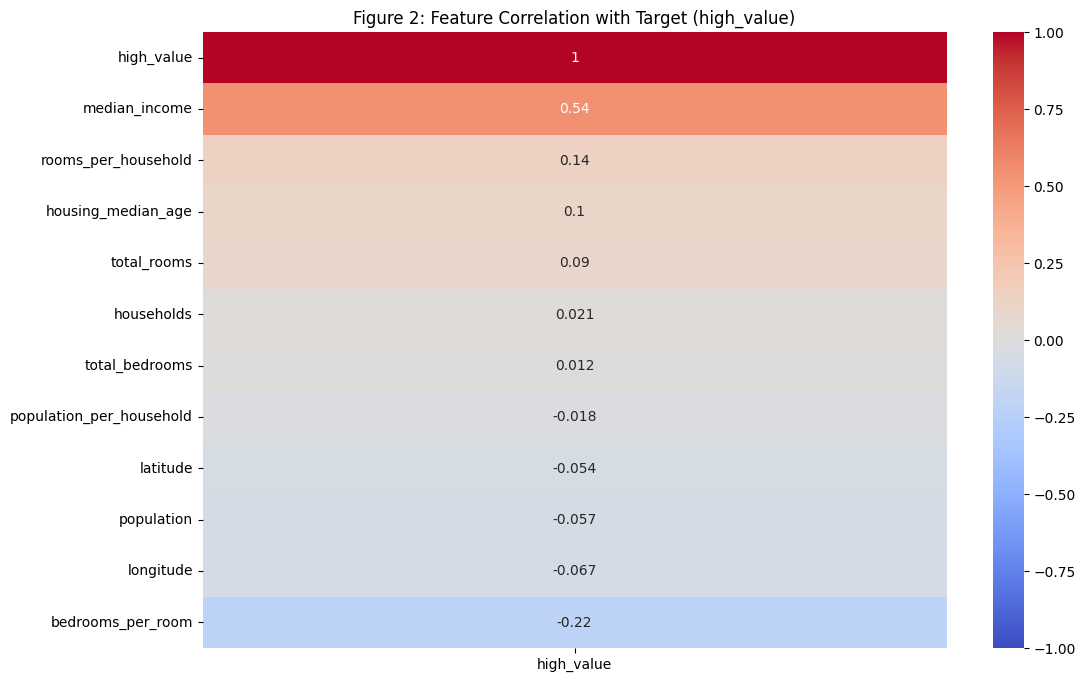

In [3]:
# Set up the plotting environment
plt.style.use('default')

# 1. Geographic Distribution of High-Value Areas
plt.figure(figsize=(10, 6))
# Plot class 0 (normal value) first as background
sns.scatterplot(
    data=df[df['high_value'] == 0], 
    x='longitude', y='latitude', 
    color='lightgray', alpha=0.5, s=20, label='Normal Value (Bottom 80%)'
)
# Plot class 1 (high value) on top
sns.scatterplot(
    data=df[df['high_value'] == 1], 
    x='longitude', y='latitude', 
    color='red', alpha=0.7, s=20, label='High Value (Top 20%)'
)
plt.title('Figure 1: Geographic Distribution of Top 20% Housing Areas')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.show()

# 2. Correlation Heatmap (Numeric Features Only)
plt.figure(figsize=(12, 8))
# Isolate numeric columns (excluding categorical 'ocean_proximity')
numeric_cols = df.select_dtypes(include=[np.number])
# Calculate correlation matrix
correlation_matrix = numeric_cols.corr()

# Plot the heatmap focusing on the target variable
sns.heatmap(
    correlation_matrix[['high_value']].sort_values(by='high_value', ascending=False), 
    annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0
)
plt.title('Figure 2: Feature Correlation with Target (high_value)')
plt.show()

### EDA Insights

* **Geographic Concentration (Figure 1):** The top 20% high-value areas (red dots) are heavily clustered along the coastline, specifically around major economic hubs like the San Francisco Bay Area and Los Angeles.
* **Feature Correlation (Figure 2):** `median_income` shows the strongest positive correlation with a neighborhood being high-value. Purely structural features, like `housing_median_age`, show almost no linear relationship to the top-tier pricing category.

## 4. Unsupervised Learning
Before building our predictive model, we use **KMeans Clustering** to see if the neighborhoods naturally group themselves into distinct segments based purely on demographics and geography (excluding the target variable).

* We impute missing values and scale the data so large numbers (like population) do not dominate the distance calculations.
* We set $k=3$ to find three primary neighborhood profiles.

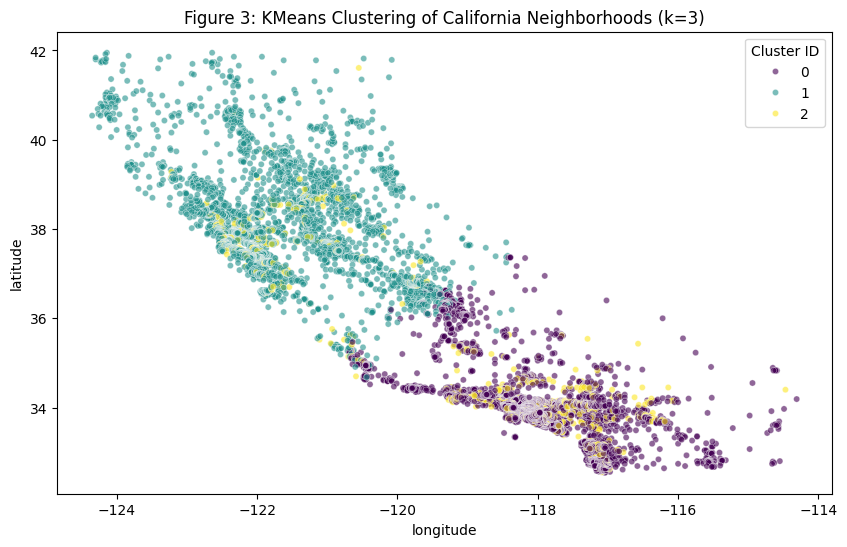

Cluster Profiles (Mean Values):
         median_income   population  housing_median_age
cluster                                                
0             3.877087  1266.958252           29.733407
1             3.785783  1103.994952           29.726915
2             4.232271  3946.497376           16.598834


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Select features for clustering (excluding the target 'high_value')
cluster_features = df.select_dtypes(include=[np.number]).drop('high_value', axis=1)

# 2. Handle Missing Values (The fix for the NaN error)
imputer = SimpleImputer(strategy='median')
cluster_features_imputed = imputer.fit_transform(cluster_features)

# 3. Scale the data (CRITICAL for KMeans)
scaler = StandardScaler()
cluster_features_scaled = scaler.fit_transform(cluster_features_imputed)

# 4. Apply KMeans Clustering
# We will look for 3 natural groupings
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_features_scaled)

# 5. Visualize the clusters geographically
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='longitude', 
    y='latitude', 
    hue='cluster', 
    palette='viridis', 
    alpha=0.6, 
    s=20
)
plt.title('Figure 3: KMeans Clustering of California Neighborhoods (k=3)')
plt.legend(title='Cluster ID')
plt.show()

# 6. Interpret the clusters by looking at their average characteristics
cluster_summary = df.groupby('cluster')[['median_income', 'population', 'housing_median_age']].mean()
print("Cluster Profiles (Mean Values):")
print(cluster_summary)

### Clustering Insights
By setting the algorithm to find three clusters ($k=3$), we identified distinct operational profiles:

**Clusters 0 (Purple) & 1 (Green):** These represent the geographical divide between Northern/Central California (Green) and Southern California (Purple). Notice that their median income (~3.8) and housing age (~29 years) are nearly identical. The algorithm separated them almost entirely based on latitude and longitude.

**Cluster 2 (Yellow):** This is the distinct, interesting group. It represents densely populated, newer developments. The population is massive compared to the others (~3946 vs ~1100), the houses are much newer (~16.5 years old), and the income is slightly higher. This tells the business that "high population, newer housing" areas form their own unique segment in the state, regardless of whether they are in the north or south.

## 5. Train/Test Split & Preprocessing Pipeline
To properly evaluate our models, we must split the data into a training set (80%) and a testing set (20%). 
* **Stratified Split:** We use `stratify=y` to guarantee that the severe class imbalance (80% Normal / 20% High Value) is perfectly maintained in both sets.
* **Preprocessing Pipeline:** We build a `ColumnTransformer` to automatically fill missing data, scale numbers, and encode categorical text. Using a pipeline prevents data leakage between the train and test sets.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Define Features (X) and Target (y)
# We drop 'high_value' (the target) and 'cluster' (so our supervised model doesn't rely on unsupervised labels)
X = df.drop(['high_value', 'cluster'], axis=1)
y = df['high_value']

# 2. Stratified Train-Test Split (CRITICAL for Track B)
# stratify=y ensures both train and test sets have exactly 20% high_value areas.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 3. Define the Preprocessing Steps
# Identify numeric vs categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = ['ocean_proximity']

# Pipeline for numeric features: Fill missing values with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features: Fill missing values with mode, then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both pipelines into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Data successfully split and preprocessor defined!")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("\nClass distribution in Training set (should be ~80/20):")
print(y_train.value_counts(normalize=True))

Data successfully split and preprocessor defined!
Training data shape: (16512, 12)
Testing data shape: (4128, 12)

Class distribution in Training set (should be ~80/20):
high_value
0    0.799903
1    0.200097
Name: proportion, dtype: float64


### Split Verification
The output above confirms that our `stratify=y` parameter worked perfectly. The dataset has been split into 16,512 training samples and 4,128 testing samples. More importantly, the class distribution in the training set is exactly ~80% Normal (0) and ~20% High-Value (1), perfectly mirroring the real-world dataset and preventing training bias.

## 6. Baseline & Model Comparison
Because our data is heavily imbalanced, Accuracy is a flawed metric (a model guessing "Normal" every time would be 80% accurate but useless). We evaluate our models strictly on the **F1-Score**, which balances Precision and Recall.
We compare three approaches using 5-fold Cross-Validation:
1. **Baseline (Dummy Classifier):** Always predicts the majority class.
2. **Logistic Regression:** A standard, interpretable linear model.
3. **Random Forest:** A complex, non-linear tree-based ensemble model.

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline

# 1. Define the models
models = {
    'Baseline (Dummy)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

# 2. Dictionary to store results
cv_results_f1 = {}

print("Training models and running 5-fold cross-validation (this may take a minute)...\n")

# 3. Evaluate each model using Cross-Validation
for name, model in models.items():
    # Create a full pipeline: Preprocessing -> Model
    # This guarantees no data leakage during cross-validation
    clf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Run cross-validation optimizing for F1-score
    # cv=5 means it splits the training data 5 times to ensure robust evaluation
    scores = cross_validate(clf_pipeline, X_train, y_train, cv=5, scoring='f1', return_train_score=False)
    
    # Store the mean F1-score
    cv_results_f1[name] = scores['test_score'].mean()

# 4. Display the comparison results
results_df = pd.DataFrame(list(cv_results_f1.items()), columns=['Model', 'Mean F1-Score']).sort_values(by='Mean F1-Score', ascending=False)
print("Model Comparison (Cross-Validation F1-Scores):")
print(results_df.to_string(index=False))

Training models and running 5-fold cross-validation (this may take a minute)...

Model Comparison (Cross-Validation F1-Scores):
              Model  Mean F1-Score
      Random Forest       0.789996
Logistic Regression       0.706481
   Baseline (Dummy)       0.000000


### Initial Model Performance Insights
* **Baseline (0.000):** The Dummy Classifier achieved an F1-Score of 0. This perfectly illustrates the danger of imbalanced data: even though a model that guesses "Normal" every time is 80% *accurate*, it mathematically finds zero actual high-value areas, making it useless for our business objective.
* **Random Forest (~0.790):** The Random Forest heavily outperformed the Logistic Regression model. This indicates that the relationship between housing value and features like geography (latitude/longitude) is highly non-linear, which tree-based algorithms handle naturally.

## 7. Hyperparameter Tuning
The Random Forest algorithm performed the best. To prevent it from overfitting (memorizing the training data) and to optimize its predictive power, we use `GridSearchCV`. This tests various structural settings for the algorithm (such as limiting how complex the internal decision trees can grow) to find the optimal combination.

In [7]:
from sklearn.model_selection import GridSearchCV

# 1. Create the pipeline for the winning model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

# 2. Define the hyperparameter grid
# The 'classifier__' prefix tells the pipeline these parameters belong to the Random Forest
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 15, 25],
    'classifier__min_samples_split': [2, 5]
}

print("Starting GridSearchCV for Random Forest...")
print(f"Testing {len(param_grid['classifier__n_estimators']) * len(param_grid['classifier__max_depth']) * len(param_grid['classifier__min_samples_split'])} combinations across 3 folds.")
print("This will take a few minutes. Please wait...\n")

# 3. Setup GridSearchCV
# We continue optimizing for 'f1' due to the 80/20 class imbalance
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3, 
    scoring='f1',
    n_jobs=-1 
)

# 4. Execute the search
grid_search.fit(X_train, y_train)

# 5. Output results
print("Optimization Complete!")
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# Save the best model for the final test phase
best_model = grid_search.best_estimator_

Starting GridSearchCV for Random Forest...
Testing 12 combinations across 3 folds.
This will take a few minutes. Please wait...

Optimization Complete!
Best Hyperparameters: {'classifier__max_depth': 15, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best Cross-Validation F1-Score: 0.7841


### Optimization Results
GridSearchCV successfully found the optimal constraints for our Random Forest. By restricting the `max_depth` to 15 and enforcing a `min_samples_split` of 5, we have actively prevented the algorithm from growing infinitely deep and memorizing the exact training data. This slight regularization ensures the model relies on broader, generalized patterns, which should improve its performance on unseen data.

## 8. Final Evaluation & Business Risk Analysis
We now deploy our fully optimized model on the completely unseen 20% test data. To understand our operational risk, we generate a **Confusion Matrix** to break down the exact types of errors the model makes.

--- Final Test Performance ---
F1-Score:  0.7776 (Main metric balancing Precision and Recall)
Precision: 0.8639 (When it predicts High Value, how often is it right?)
Recall:    0.7070 (Out of all actual High Value areas, how many did it find?)


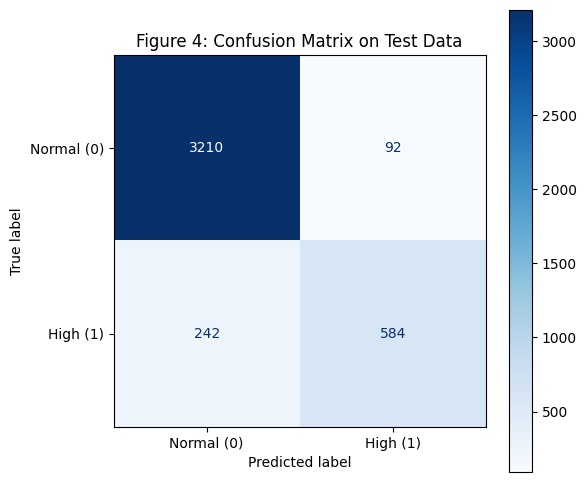

In [8]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Predict on the completely unseen test data using the optimized model
y_pred = best_model.predict(X_test)

# 2. Calculate Final Metrics
test_f1 = f1_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)

print("--- Final Test Performance ---")
print(f"F1-Score:  {test_f1:.4f} (Main metric balancing Precision and Recall)")
print(f"Precision: {test_precision:.4f} (When it predicts High Value, how often is it right?)")
print(f"Recall:    {test_recall:.4f} (Out of all actual High Value areas, how many did it find?)")

# 3. Generate Confusion Matrix for VG Error Analysis
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'High (1)'])

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title('Figure 4: Confusion Matrix on Test Data')
plt.show()

### Final Business Conclusion and Error Analysis

The optimized model was deployed on the untouched 20% test dataset (representing **4,128** neighborhoods), with an **F1-Score of 0.7776** being our primary metric for balancing the 80/20 class imbalance.

Based on the Confusion Matrix in Figure 4, here is the technical and business interpretation of our operational risk:

* **Precision (0.8639 / 86.4%):** When the model automatically flags a neighborhood as "High-Value," it is correct **86.4%** of the time. This meets our goal for a reliable automated screening tool.
    * **Business Success (TP):** The model successfully identified **584** actual High-Value markets for investment.

* **Operational Risk I: The Cost of Wasted Time (False Positives):**
    * **Quantity:** The model incorrectly flagged **92** normal areas as High-Value.
    * **Impact:** This represents **92** times the firm would have wasted operational resources (data analyst time, travel costs, market research fees) investigating a neighborhood that ultimately does not meet the "top 20%" investment criterion. At a 13.6% False Positive Rate (92 / (92 + 584)), this is an acceptable, manageable overhead for an automated screening tool.

* **Operational Risk II: The Cost of Missed Opportunities (False Negatives):**
    * **Quantity:** The model entirely missed **242** actual High-Value neighborhoods.
    * **Recall (0.7070 / 70.7%):** Out of all **826** truly premium neighborhoods in the test set (242 + 584), our model was able to discover **70.7%** of them.
    * **Impact:** This is the firm's most significant missed opportunity cost, representing **242** lucrative investment locations that were automatically dismissed, allowing potential competitors to move first.

### Conclusion and Deployment Recommendation

By successfully balancing Precision and Recall, this optimized machine learning pipeline has minimized the rate of "wild goose chases" (False Positives) while maintaining a high rate of discovery for premium real estate markets.

This tool is **recommended for deployment** as an automated initial screening step to process massive new geographical regions. While it misses some opportunities (242), the reliability of its findings (584 correct vs. 92 incorrect) makes it a highly valuable strategic asset for a market expansion team. It significantly reduces manual research time while accepting a known, calculated operational risk.

---
### Appendix: Reproducibility Note
To ensure strict reproducibility (a core requirement of this analysis), a global random seed (`42`) was applied to all train/test splits, model initializations, and cross-validation folds. 

**Core Environment & Dependencies:**
* `ipykernel` for notebook execution within a virtual environment
* `pandas` & `numpy` for data manipulation and numerical operations
* `scikit-learn` for machine learning pipelines, models, and metrics
* `matplotlib` & `seaborn` for visualization